# Week 5 - Bivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Lesson: Bivariate graphs

In this lesson, we'll consider some bivariate plots: scatter plots, line plots, waterfall plots, area plots, and pair plots.  We'll also look at bivariate statistics such as correlations, ratios, and percentages.  First, let's create some data.

In [2]:
np.random.seed(0)
numpoints = 100
lesson_series_uniform = np.round(np.random.random(size = numpoints) * 100, 2)
lesson_series_base = np.round(np.random.random(size = numpoints)**2 * 100, 2)
lesson_series_skewed = lesson_series_base + np.random.normal(scale = 10, size = numpoints)
lesson_series_reverse = 100 - lesson_series_base + np.random.normal(scale = 10, size = numpoints)

This scatter plot puts one series against another.  The two series are anticorrelated - one goes up when the other goes down.

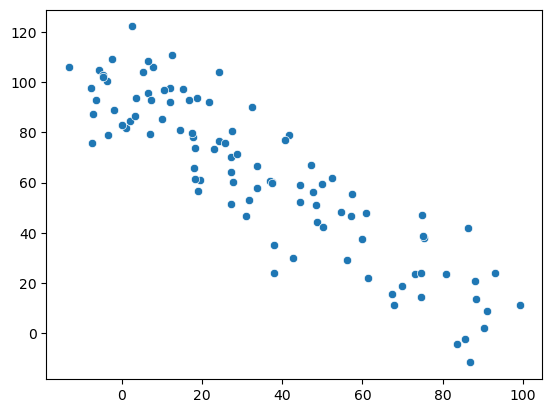

In [3]:
sns.scatterplot(x = lesson_series_skewed, y = lesson_series_reverse);

This pair plot compares three series against one another.  The diagonal shows the histogram of each series, while the non-diagonal entries plot two different series against each other.  The result in column 1, row 2 is a scatter plot that compares series #1 with series #2.  In effect, when the logic of the pair plot tells us to plot a series against itself (column 1, row 1), we draw a histogram.  (It would be silly to draw a scatter plot of a series against itself).  Because series #1 is not based on the "base" series, it is not correlated with series #2 or series #3, so the four scatter plots that compare series #1 to #2 and #3 look patternless.  The two scatter plots that compare series #2 with series #3 do appear to be correlated due to the "base" series that they share in common.

In [4]:
df = pd.DataFrame(np.array([lesson_series_uniform, lesson_series_skewed, lesson_series_reverse]).T, columns = ['uniform', 'skewed', 'reverse'])

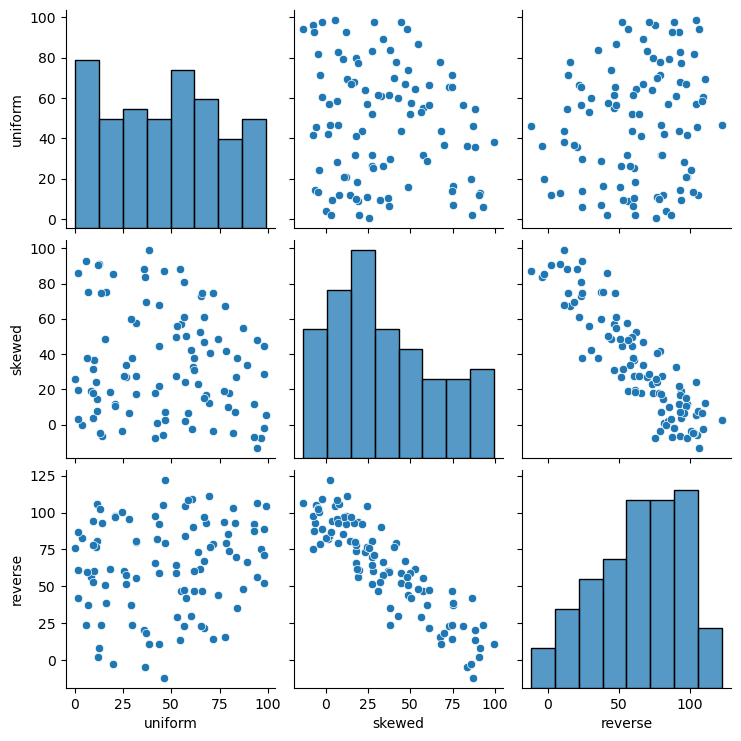

In [5]:
sns.pairplot(df);

We can compute the correlation coefficience between each pair.

In [6]:
print("Correlations:", df.corr())

Correlations:           uniform    skewed   reverse
uniform  1.000000 -0.145022  0.149771
skewed  -0.145022  1.000000 -0.894549
reverse  0.149771 -0.894549  1.000000


This shows that there is a strong negative correlation between the "skewed" and "reverse" datasets (a larger negative number in row 2, column 3 and in row 3, column 2) and almost no correlation between the "uniform" dataset and the others (the much smaller numbers at those locations in the table.)

Q: What is a correlation telling us?

If the correlation is large (close to 1) it tells us that the two variables are usually either both large or both small in value.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the lower left to upper right.

If the correlation is very negative (close to -1), it tells us that when one variable is large, the other is small.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the upper left to lower right.

If the correlation is zero, it tells us that the two variables, plotted on a scatter plot, would form a cloud.  The cloud can have different shape - for instance, it could be square or circular - but it cannot look like a diagonal line.  Knowing the value of one variable would tell you nothing about the value of the other variable.  (At least, it would not tell you whether the other variable is large or small).

The correlation coefficients above are called by the letter R.  R can be positive or negative, and lies between -1 and 1.  If we square R, we get a value called $R^2$ which is sometimes used to describe the correlation.  Unless R = 0 or 1, $R^2$ will be smaller in magnitude than R (and always positive), which means that it is very important to know if you are talking about R or $R^2$.  Since the values above can be negative, you can know for sure that they are R values, not $R^2$.

Q: How do you decide if a correlation is strong?

It depends on the application.  Some sources say that a correlation of R = 0.7 or 0.8 is strong, but in other applications (say, the social sciences) a correlation of 0.5 might be considered quite strong.  It is not unusual for social scientists to report correlations even as low a 0.2 as being important.

Q: What is the purpose of finding a correlation?

Here are a few:

1. Variables that are correlated with a target variable might be especially useful in predicting that variable.  This might also suggest that a linear model could work.  On the other hand, just because there are no pairwise correlations doesn't mean that a linear model won't work.  For example, if you select X, Y, and Z from this list of four possibilities: \[\[X = 1, Y = 0, Z = 0], \[X = 0, Y = 1, Z = 0], \[X = 0, Y = 0, Z = 1], \[X = 1, Y = 1, Z = 1]] then any two variables are completely uncorrelated, but the sum of the three is usually 1.  So the linear model Z = 1 - X - Y is accurate in three out of four cases even though all pairwise correlations are zero.

2. Variables that are very correlated with each other might be redundant.  In the extreme case, two variables that have a correlation of 1.0 are "linearly dependent" - they essentially provide the same information.  For example, if one column is a height in inches, and another is a height in centimeters, then they are redundant.  Moreover, if you use two highly correlated variables as predictors, the results will be somewhat unpredictable.  For example, if HI is the height in inches and HC is the height in centimeters, then the following formulas are all equivalent: HC, 2.54 * HI, 0.5 * HC + 1.27 * HI, 1001 * HC - 2540 * HI.  So there's no knowing which one you'll get if you try to build a model based on these variables.  The last one in particular is a little bit surprising, given the large coefficients, but it could very well be the result of a linear regression analysis.

3. Correlation can help you to detect problems with the data.  If two variables are correlated but shouldn't be, or if they're not correlated but should be, there might be something wrong with the data.  It's important to test the data to see if it makes sense.

4. Correlations can be interesting things to report.  If your client or organization is asking for a verbal explanation of the dataset, they might be interested in knowing about any correlations for reasons of their own.

A waterfall chart shows a value after a sequence of inputs and outputs.

In [7]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name='This title is not displayed',
    orientation='v',
    measure=['absolute','relative','relative','relative','relative'],
    x=["2023-Jan", "receipts-in", "interest-in", "expenses-out", "interest-out", "2024-Jan"],
    textposition='outside',
    text=['Total','after-receipts','after-interest','after-expenses','after-interest'],
    y=[123.45,42.08,21.97,-54.31,-50.23],
    connector=dict(line=dict(color='rgb(63, 63, 63)'))
))

fig.update_layout(
    title='Waterfall Plot',
    showlegend=False
)
fig.update_yaxes(range=[-1,230])
fig.show()

A line plot is typically associated with a time or date range.  It shows how a variable rises and falls over a period of time.

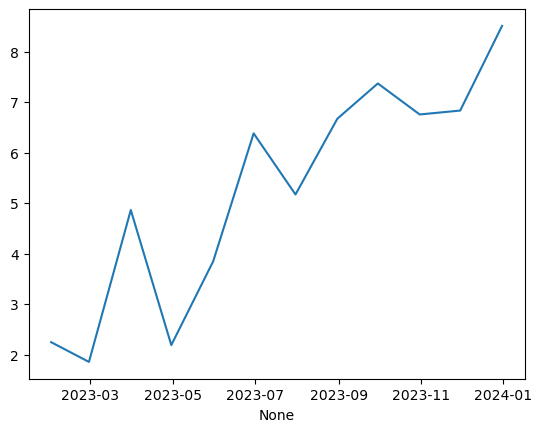

In [8]:
numdates = 12
time_series = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
sns.lineplot(x = datearray, y = time_series);

An area plot stacks one curve on top of another.  In the graph below, the top line shows the sum of the two series (ser1 + ser2) while the bottom line just shows ser1.

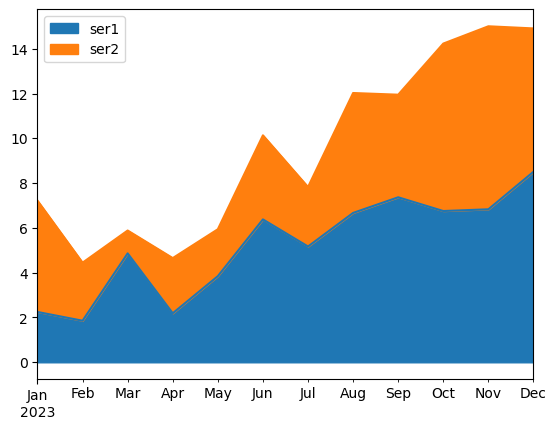

In [9]:
time_series_2 = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area();

# 2. Weekly graph question

Below is a pair plot showing the correlation between the levels of chemical A, B, and C in a water sample.  If you had to choose just _three_ of the nine graphs in the pair plot to display, which would you choose?  How would you alter the way these graphs are displayed to make them clearer or more informative?  Would you fit any of these graphs to a line or curve?  Why or why not?  What if you had to choose just _one_?  What if you had to choose _six_?

In [10]:


np.random.seed(0)
num_data = 100
base_data = np.random.random(size = num_data)
chem1 = base_data + np.random.normal(size = num_data) * 0.1
chem2 = base_data**2 + np.random.normal(size = num_data) * 0.1
chem3 = 1 - base_data + np.random.normal(size = num_data) * 0.1
df_chem = pd.DataFrame({'chem1':chem1,'chem2':chem2,'chem3':chem3})

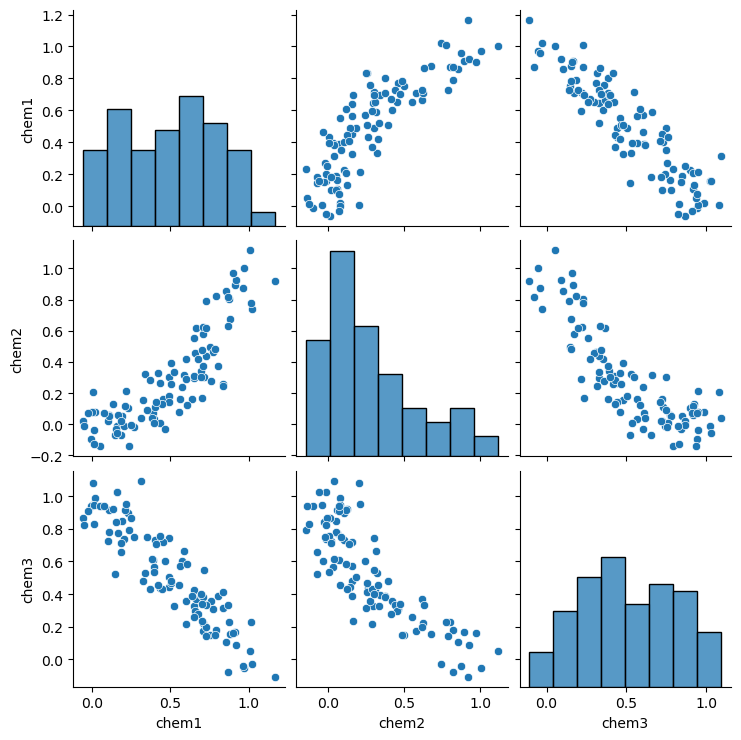

In [11]:
sns.pairplot(df_chem)

<b>Which graphs to choose:</b><br/>
in the above diagram I would choose the following plots:<br/>
4, 6, 7<br/>
if the above is read as<br/>
1&#9;2&#9;3<br/>
4&#9;5&#9;6<br/>
7&#9;8&#9;9<br/>

<b>Change to any formatting</b>:<br/>
The graph above may be easier to interpret if the title and x and y axes were more explanative. For instance if they represent the correlation between the two items being plotted than a title something to the affect "Correlation Plot of Chemicals 1, 2, and 3." The actual names of the checmicals might be included in the title and the axes.  It would also help if each subplot had text which designated what is being displayed, so one doesn't have to keep referring to the gideson the x and y axes.

<b>Use a different representation?</B><br/>
I would probably set graph number 4 to include a linear model line. #6 might be an interesting curve. These two lend themselse to that representation easily, while the others may not.

<b>If I had to choose just one graph</b> out of the above it would be #4, I would be interested in the correlation there seems to be and what that would reveal.

<b>Choose 6 graphs</b><br/>
I would not choose the histograms.

# 3. Homework - Reproducing Pair Plot Graphs

I'm going to show you some Pair Plot (Scatter and Histogram) graphs.  I'd like you to generate some data that will generate those graphs.

Example: this cloud involves a match between two normal distributions.

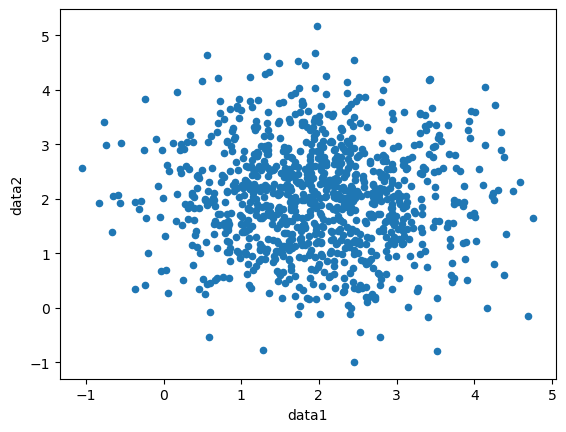

In [12]:
num_points = 1000
np.random.seed(0)
data1 = np.random.normal(size = num_points) + 2
data2 = np.random.normal(size = num_points) + 2
df_twonorm = pd.DataFrame({"data1":data1,"data2":data2})
df_twonorm.plot.scatter(x = "data1", y = "data2");

Problem: Can you design data that will generate the following scatter plot?  You may need to join multiple series to make one big series for the y-axis data.  That will allow you to create the two clouds. Use Google or ChatGPT to find the function that does that.  It is okay if the precise numbers are not re-created; just the general shape: two vertically separated clouds of points.

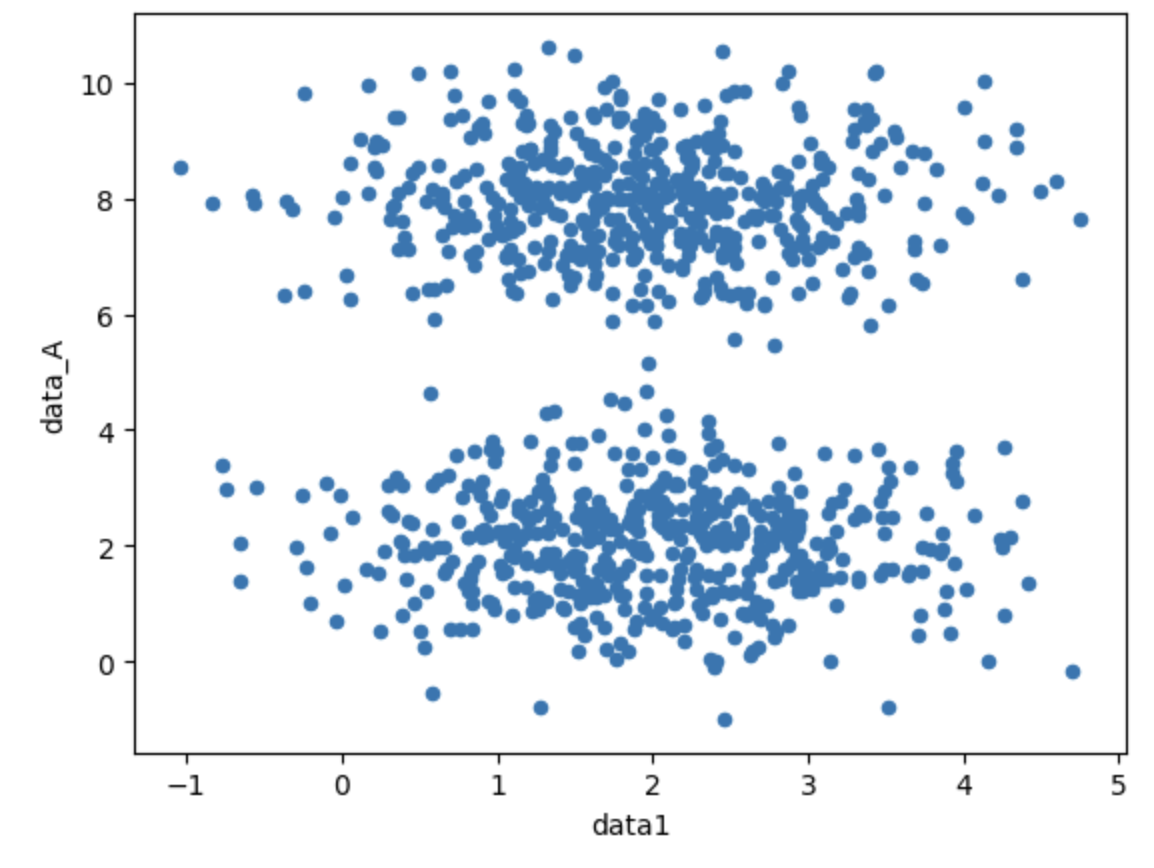

In [13]:
from IPython.display import Image
Image("twoclouds.png")

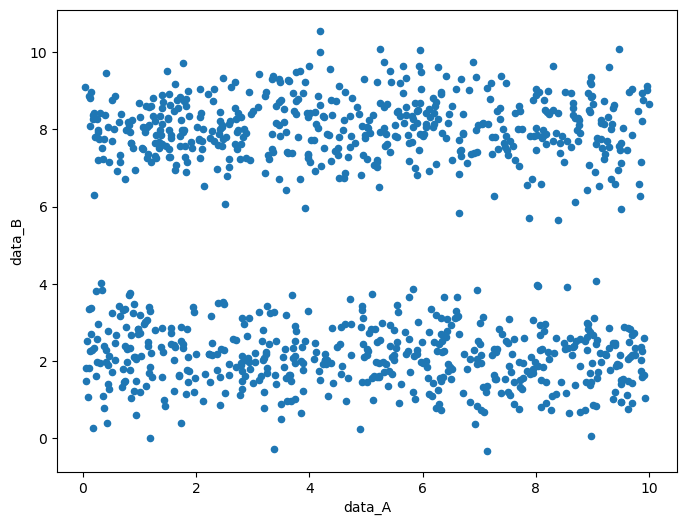

In [14]:
num_points = 500
np.random.seed(42)

# Parameters for x clouds
cloud_x = 0
cloud_y = 10
# Parameters for y clouds
cloud_loc = 2
cloud_scale = 0.8

# Create x data (same x values for both clouds)
x_cloud1 = np.random.uniform(cloud_x, cloud_y, num_points)
x_cloud2 = np.random.uniform(cloud_x, cloud_y, num_points)

# Create two y clouds with different means (vertically separated)
y_cloud1 = np.random.normal(loc=cloud_loc, scale=cloud_scale, size=num_points)  # Lower cloud around y=2
y_cloud2 = np.random.normal(loc=cloud_loc + 6, scale=cloud_scale, size=num_points)  # Upper cloud around y=8

# Concatenate x and y data to create one big series
x_combined = np.concatenate([x_cloud1, x_cloud2])
y_combined = np.concatenate([y_cloud1, y_cloud2])

# Create DataFrame and plot
data_A = x_combined
data_B = y_combined
df_twoclouds = pd.DataFrame({"data_A": data_A, "data_B": data_B})
df_twoclouds.plot.scatter(x="data_A", y="data_B", figsize=(8, 6));

In [15]:
# Exploratory Data Analysis (EDA) of the District Cost Dataset
# The dataset contains information about the costs incurred by different school districts. The columns include:
# - Year: The year for which the data is recorded. - year
# - District: The ID of the school district. - leaid
# - Average District Cost per Student: The average District cost per student. - ppcstot
# - Average National Cost required: The cost required to meet certain standards or requirements. - predcost
# - Gap between District cost and National cost - fundinggap
# - Gap between National test score average and District test score average: The difference between the national average test scores and the district's average test scores. - outcomegap
# - Percent of students in the district who are deemed to be in poverty. - pov
# - Percent of Hispanic Students in each district. - hisp
# - Percent of Black Students in each district. - black
# - Percent of White Students in each district. - white
# - Percent of Asian Students in each district. - asian
# - Percent of Students in each district who are Multiracial. - multi
# - Percent of Students in each district who are English Language Learners. - ell
# - Percent of Students in each district who are American Indian or Alaska Native. - amind
# - Percent of Students in each district who are Native Hawaiian or Other Pacific Islander. - pac
# - Percent of Students in each district who are in Special Education. - iep

# Load the dataset
dcd25 = pd.read_csv("..\dcd_2025.tsv", sep="\t", engine='python')
dcd25

,year,leaid,district,state_name,stabbr,ppcstot,predcost,fundinggap,outcomegap,enroll,...,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64
0,2022,100005,ALBERTVILLE CITY,Alabama,AL,10266,13358,-3092,NaN,5956,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,100030,ALEXANDER CITY,Alabama,AL,12566,19503,-6937,NaN,2927,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,100060,ANDALUSIA CITY,Alabama,AL,11436,17564,-6128,NaN,1862,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022,100090,ANNISTON CITY,Alabama,AL,13896,33488,-19592,NaN,1908,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,100100,ARAB CITY,Alabama,AL,10682,9721,961,NaN,2645,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170999,2009,5604500,UINTA COUNTY SCHOOL DISTRICT #4,Wyoming,WY,14008,7066,6942,-0.040183,730,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171000,2009,5604260,UINTA COUNTY SCHOOL DISTRICT #6,Wyoming,WY,15735,7658,8077,-0.035458,672,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171001,2009,5606240,WASHAKIE COUNTY SCHOOL DISTRICT #1,Wyoming,WY,14987,9831,5156,0.342768,1306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171002,2009,5604830,WESTON COUNTY SCHOOL DISTRICT #1,Wyoming,WY,14750,8614,6136,0.005301,820,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


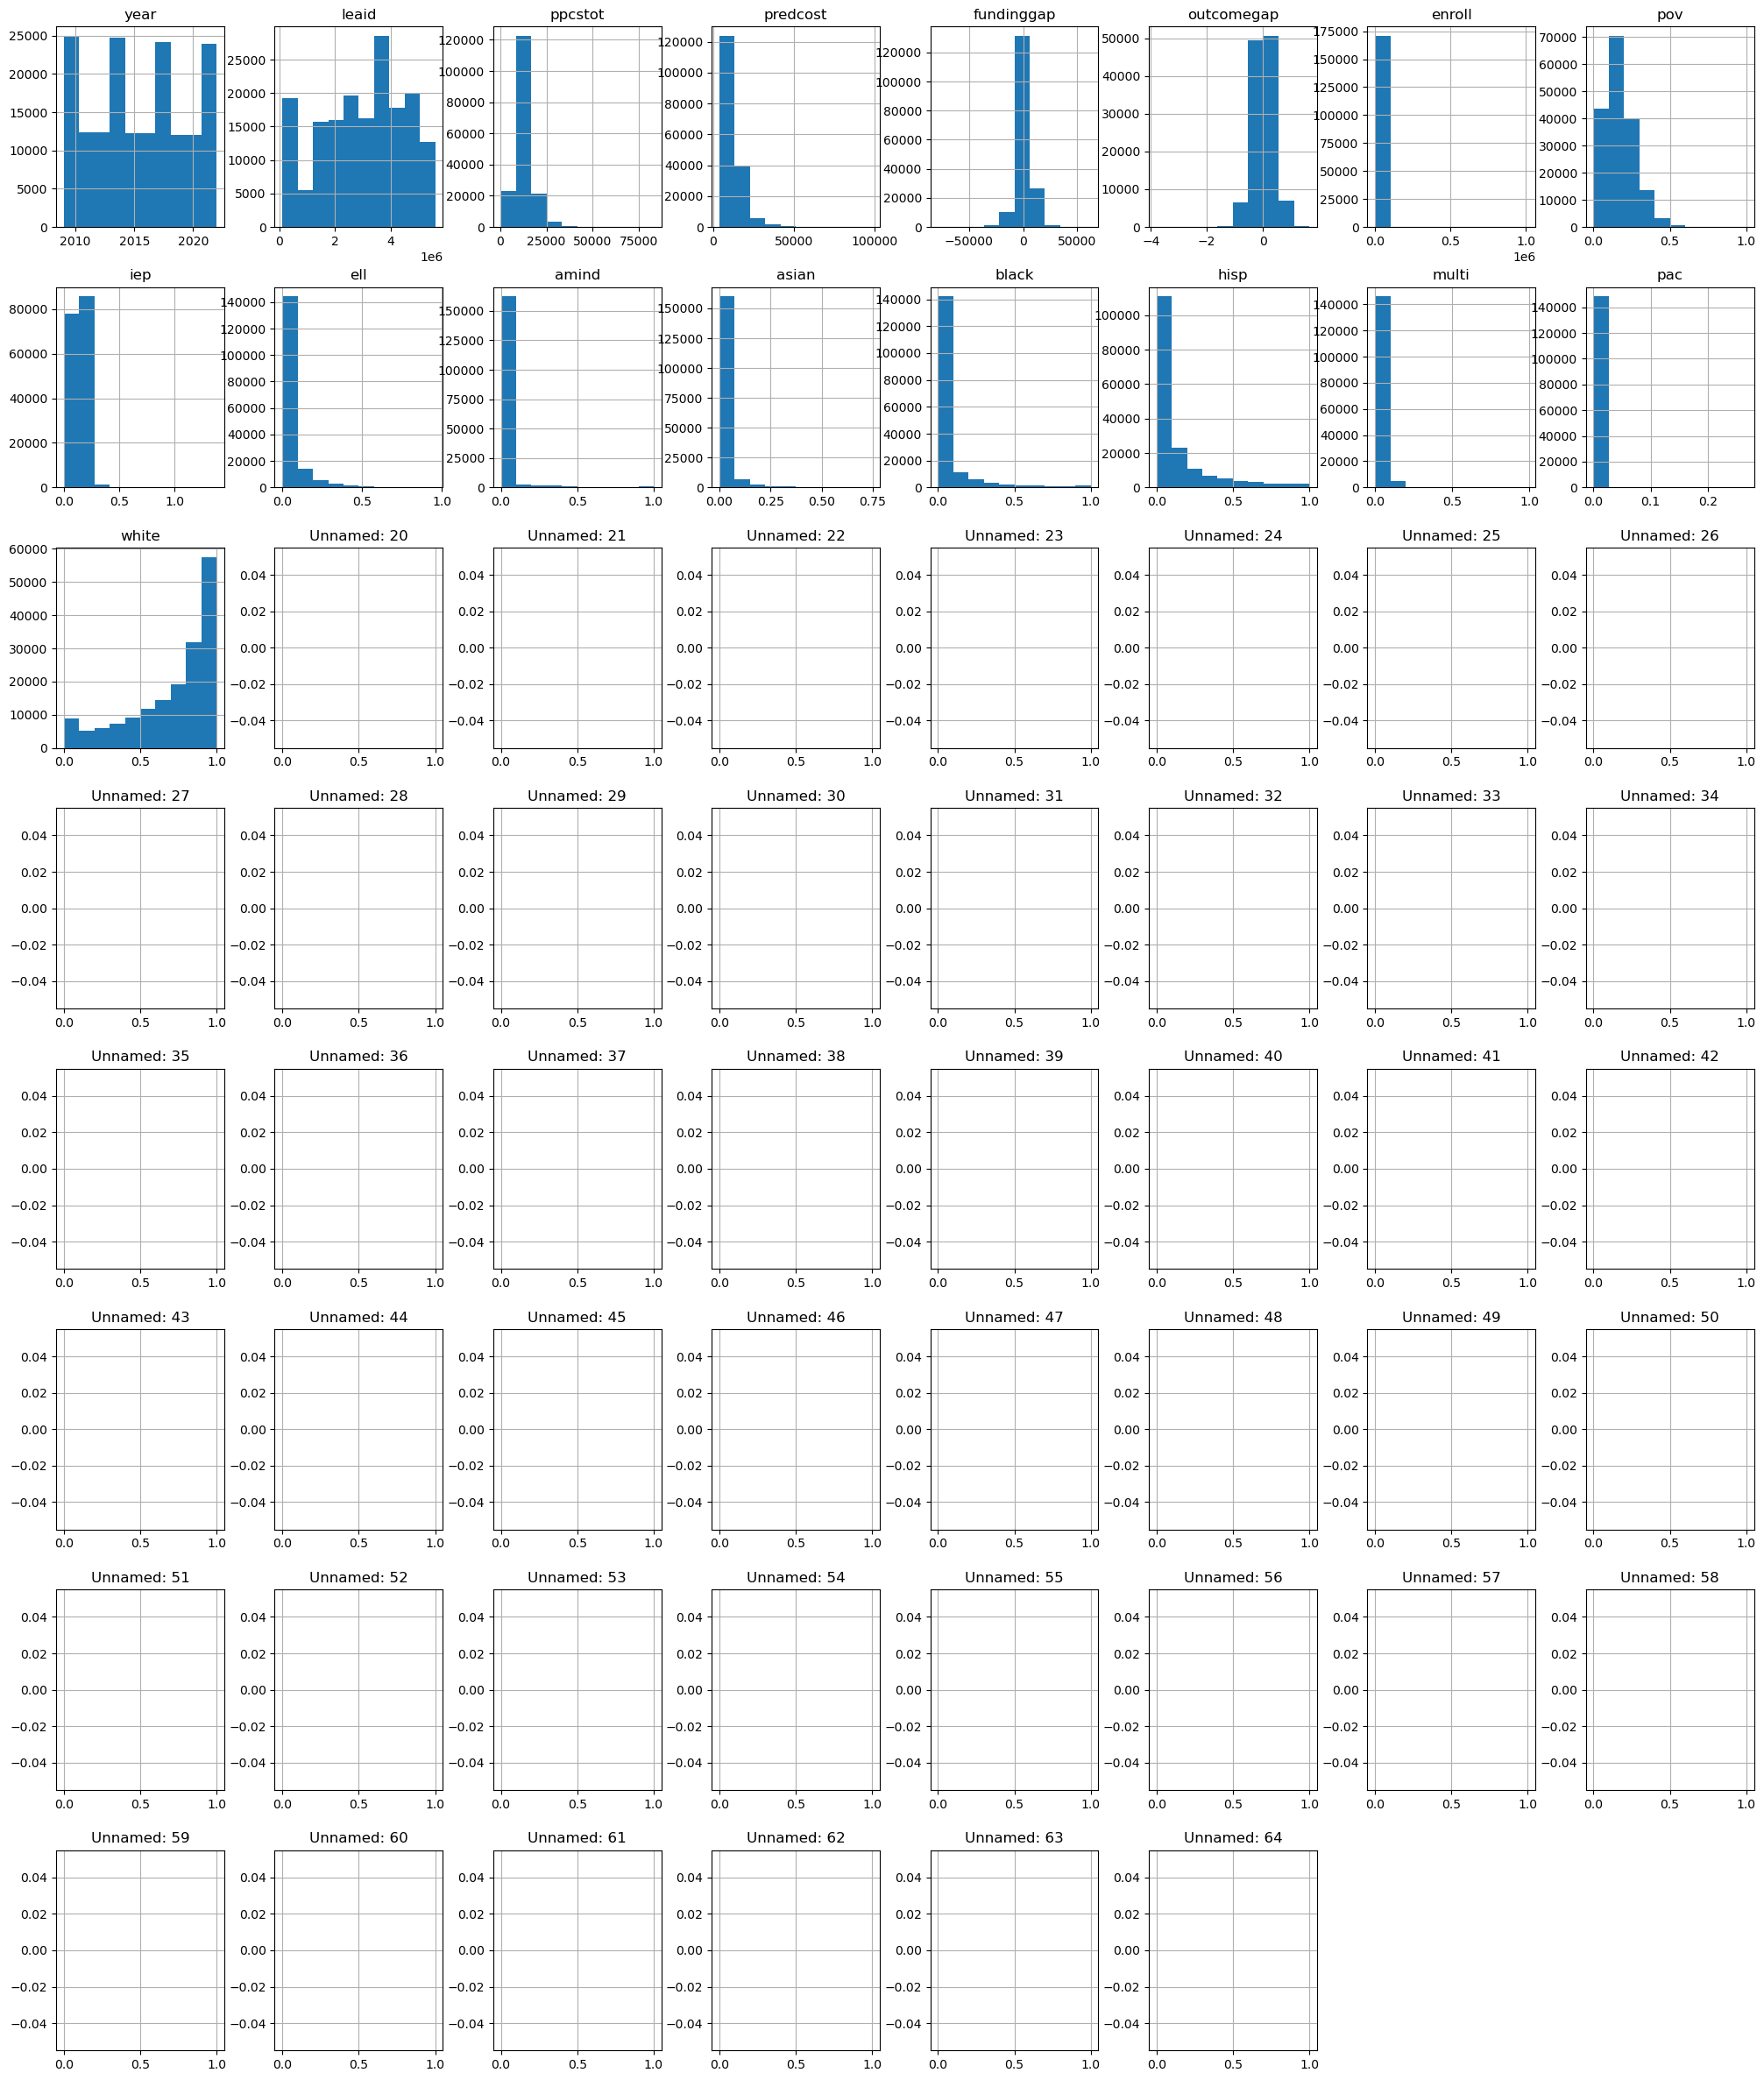

In [16]:
figsize = (25, 30)
dcd25.hist(figsize=figsize);

In [17]:
def show_missing_columns(df, lower_bound, upper_bound):
    missing_percent = (df.isnull().sum() / len(df)) * 100
    filtered_missing = missing_percent[(missing_percent > lower_bound) & (missing_percent <= upper_bound)]
    count = len(filtered_missing)
    
    # Generate markdown table
    table_df = filtered_missing.reset_index()
    table_df.columns = ['Column', 'Missing %']
    table_df['Missing %'] = table_df['Missing %'].round(2)
    print(f"There are \033[1m{count}\033[0m columns with missing values between {lower_bound}% and {upper_bound}% in this dataset.")
    
    return filtered_missing, count

In [18]:
dcd25_Percent95, dcd25_percent95_count = show_missing_columns(dcd25, 95, 100)

There are 45 columns with missing values between 95% and 100% in this dataset.


In [19]:
dcd25_new = dcd25.drop(columns=dcd25_Percent95.index.tolist())
dcd25_renamed = dcd25_new.rename(columns={'predcost': 'req_spending', 'ppcstot': 'actual_spending', 'ell': 'per_eng_learn', 'leaid': 'district_id', 'iep': 'per_speced', 'fundinggap': 'req_actual_diff', 'outcomegap': 'testscore_gap', 'amind': 'per_amerindian', 'asian': 'per_asian', 'black': 'per_black', 'hisp': 'per_hispanic', 'white': 'per_white', 'multi': 'per_multi', 'pac': 'per_pac_hi'})

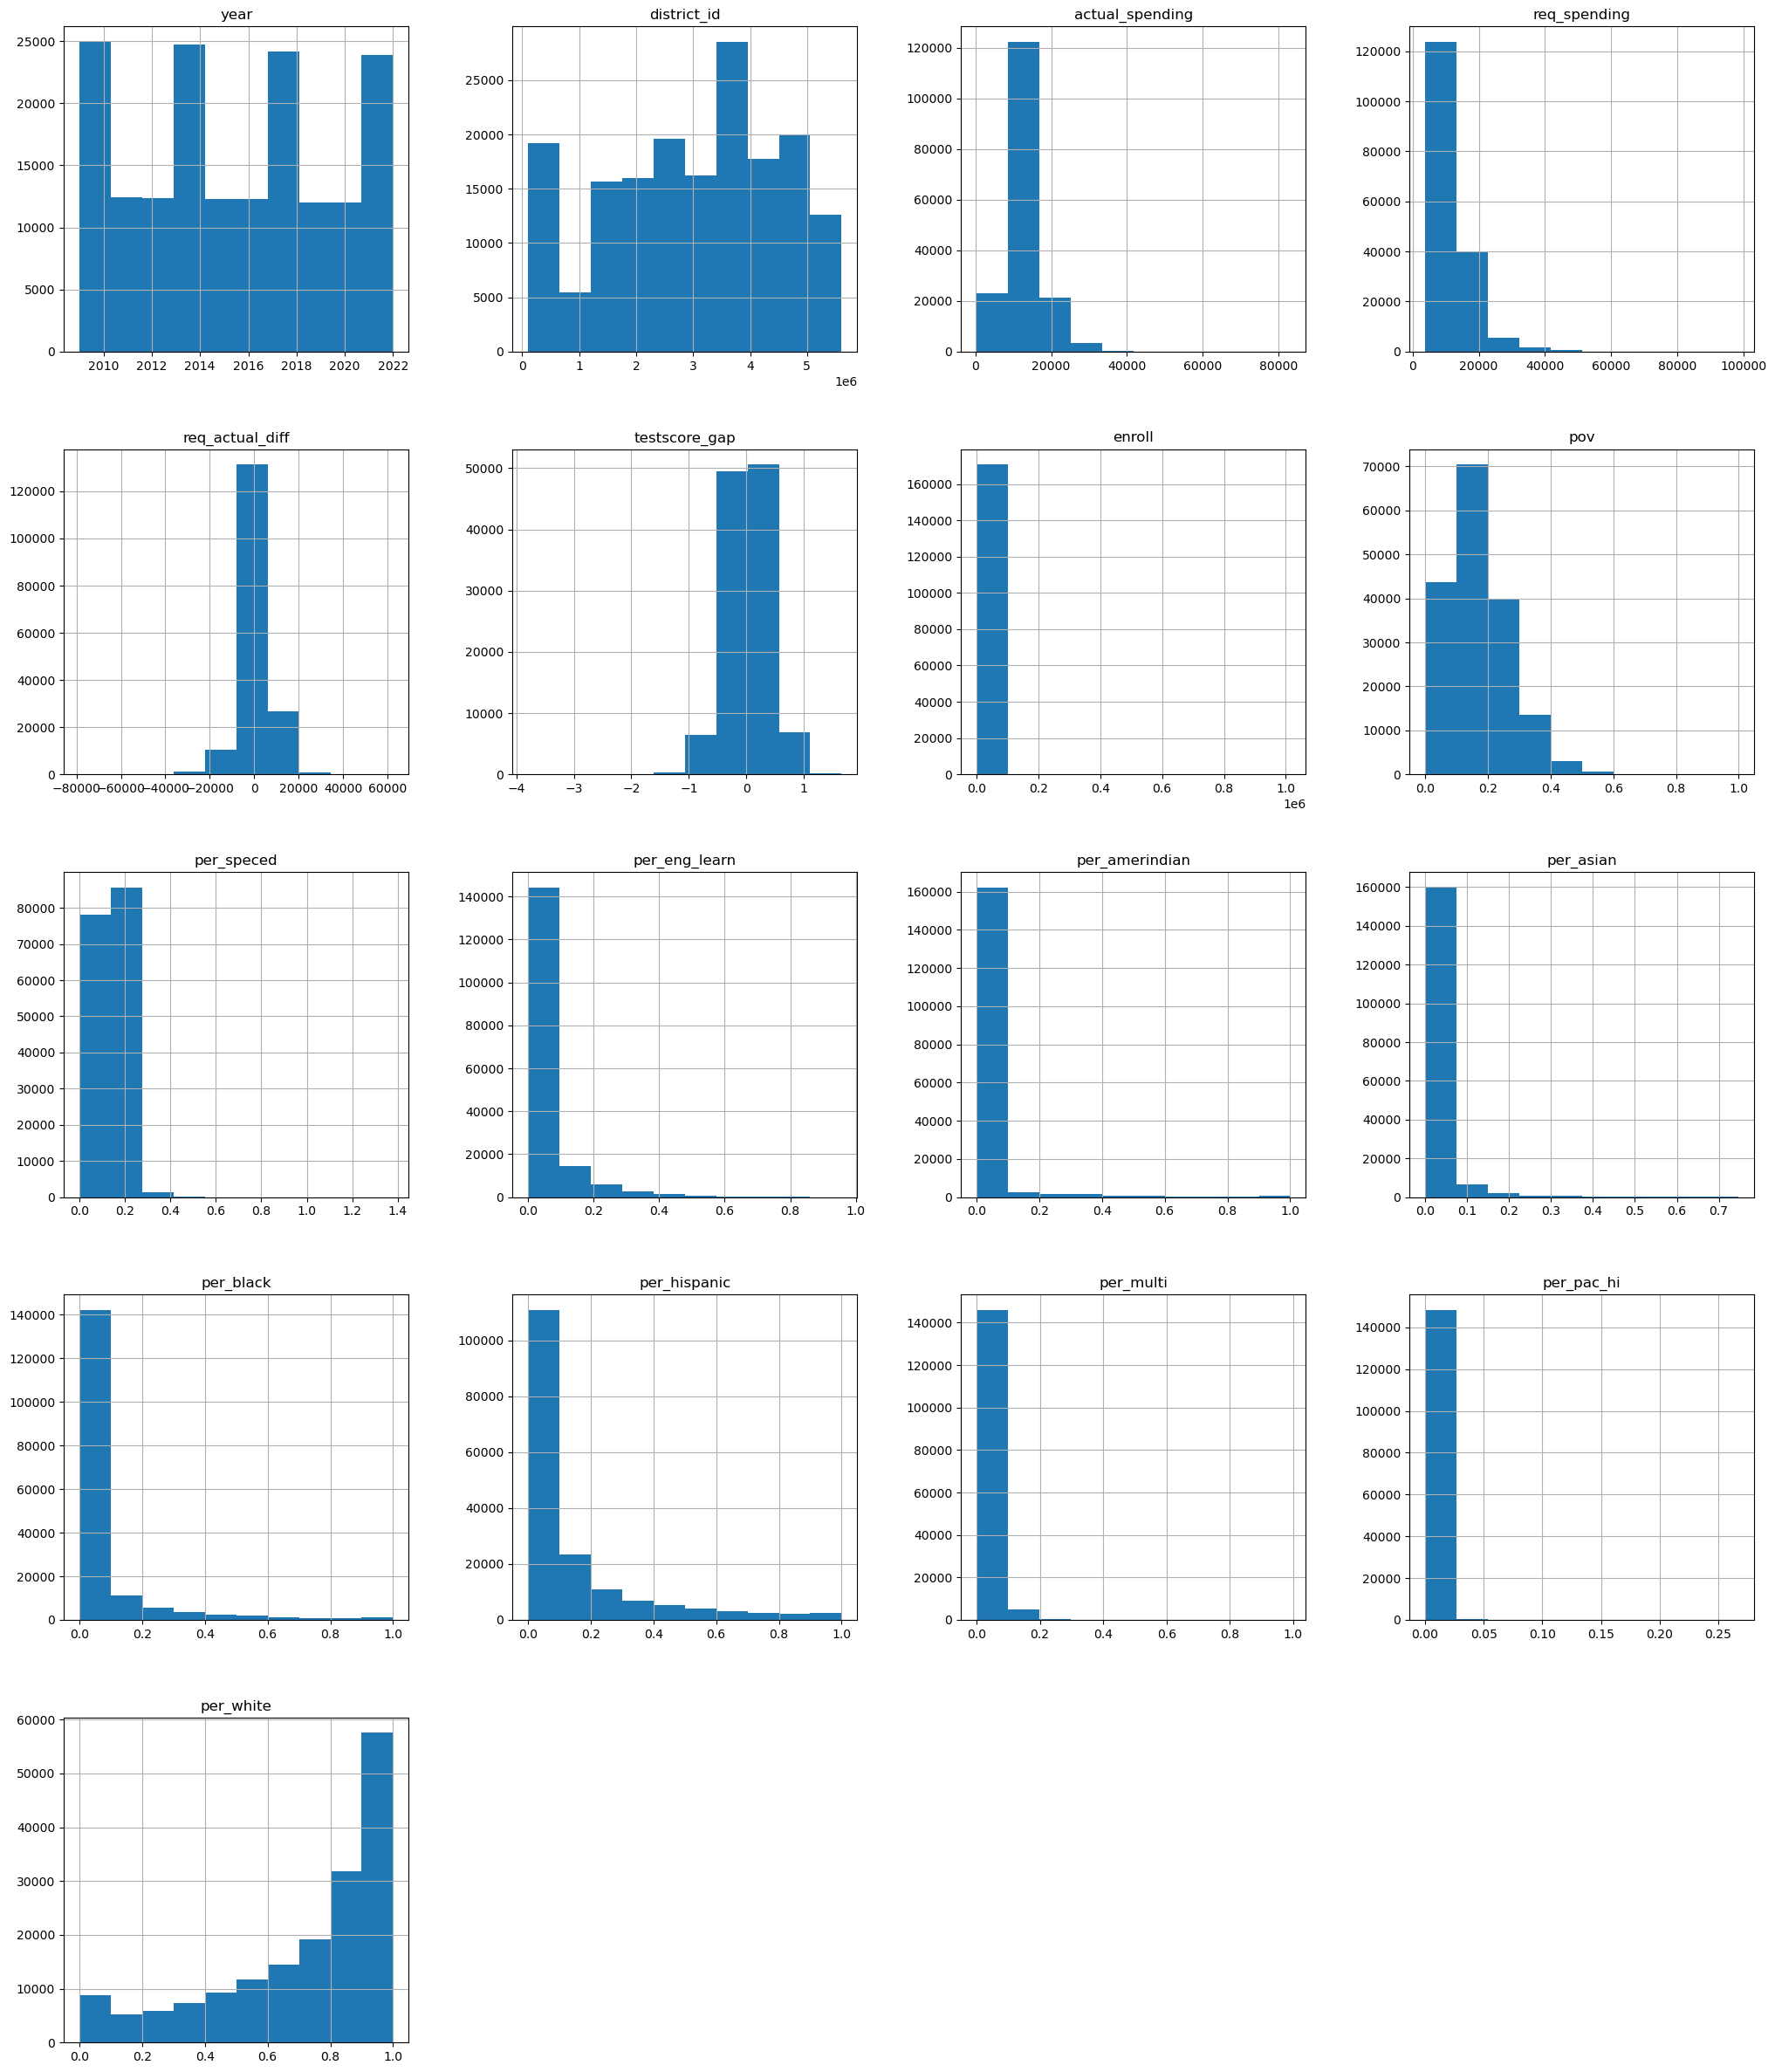

In [20]:
figsize = (25, 30)
dcd25_renamed.hist(figsize=figsize);

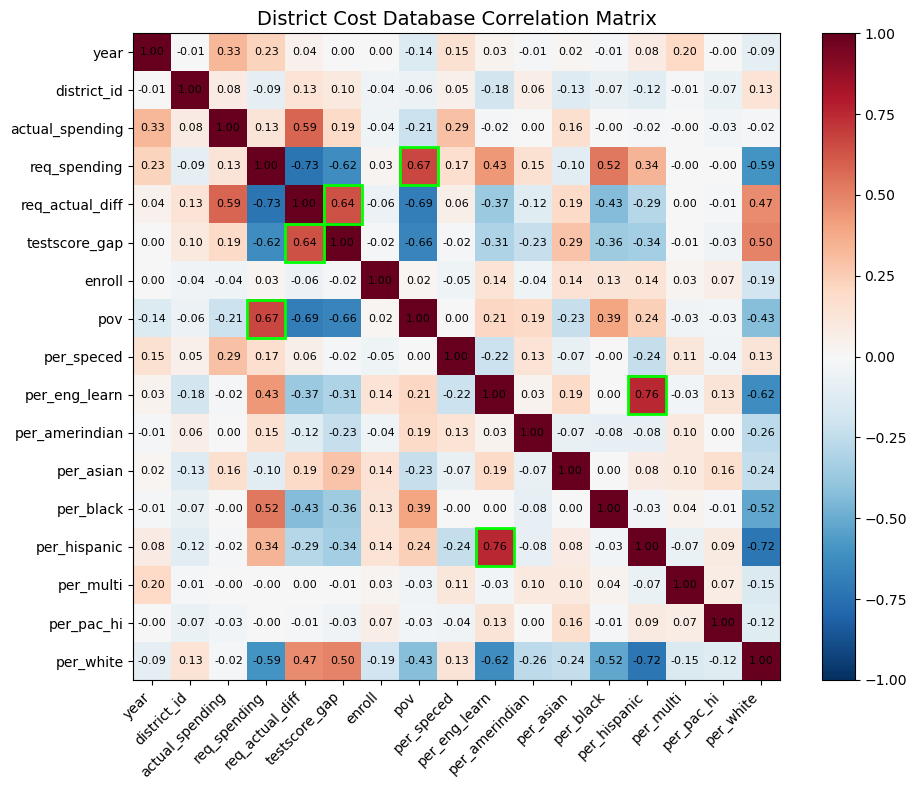

In [21]:
# note that the cost difference between requested and actual spending correlates relatively highly with the test score gap 
# this might be useful for further analysis
# for instance, could this be due to the specific district's characteristics?

# also note that the percent of ELL highly correlates to the percent of Hispanic students, this
# might be due to a large number of ELL students being Hispanic and may require further analysis

# Create correlation matrix for dcd25_renamed
# use only numeric columns
dcd25_numeric_columns = dcd25_renamed.select_dtypes(include=['int64', 'float64']).columns.tolist()
dcd25_numeric_data = dcd25_renamed[dcd25_numeric_columns]
dcd25_correlation_matrix = dcd25_numeric_data.corr()

# Add text annotations and highlight specific cells
plt.figure(figsize=(10, 8)) # use figsize to adjust the size of the plot
dcd25_cmap = plt.cm.RdBu_r # Red-Blue colormap for better visibility of positive and negative correlations

im = plt.imshow(dcd25_correlation_matrix, cmap=dcd25_cmap, vmin=-1, vmax=1)
plt.colorbar(im)

# Add text annotations
for i in range(len(dcd25_numeric_columns)):
    for j in range(len(dcd25_numeric_columns)):
        text = plt.text(j, i, f'{dcd25_correlation_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

# Find and highlight only high POSITIVE correlation points (excluding diagonal)
correlation_threshold = 0.6  # Adjust this value as needed
highlight_points = []
for i in range(len(dcd25_numeric_columns)):
    for j in range(len(dcd25_numeric_columns)):
        # Removed abs() to only highlight positive correlations
        if i != j and dcd25_correlation_matrix.iloc[i, j] > correlation_threshold:
            highlight_points.append((i, j))

# Highlight the high correlation points with rectangles
for row, col in highlight_points:
    rect = plt.Rectangle((col - 0.5, row - 0.5), 1, 1, fill=False, 
                         edgecolor='lime', linewidth=2)
    plt.gca().add_patch(rect)

plt.title('District Cost Database Correlation Matrix', fontsize=14)
plt.xticks(np.arange(len(dcd25_numeric_columns)), dcd25_numeric_columns, rotation=45, ha='right')
plt.yticks(np.arange(len(dcd25_numeric_columns)), dcd25_numeric_columns)
plt.tight_layout()
plt.show()
plt.savefig('dcd25_correlation_matrix.png', dpi=300)
plt.close()

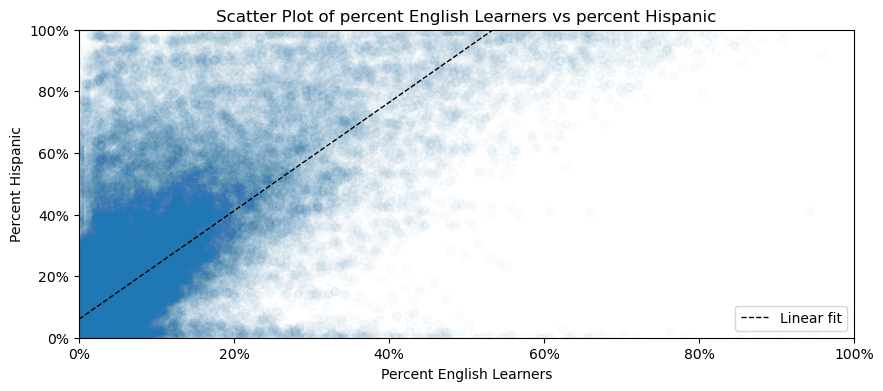

In [22]:
scatterplt = plt.figure(figsize=(10, 4))
ax = scatterplt.add_subplot(1, 1, 1)

x = dcd25_renamed["per_eng_learn"]
y = dcd25_renamed["per_hispanic"]

# Keep only finite values within 0–1 (percent as proportion)
mask = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
x_clean = x[mask]
y_clean = y[mask]

ax.scatter(x_clean, y_clean, alpha=0.02)

m, b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
y_line = m * x_line + b
ax.plot(x_line, y_line, color="black", linewidth=1, label="Linear fit", linestyle="--")
ax.legend()

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Scatter Plot of percent English Learners vs percent Hispanic")
ax.set_xlabel("Percent English Learners")
ax.set_ylabel("Percent Hispanic")
plt.show()
plt.close()

Challenge problem!  Hint: you will need two series, and three segments of the first series will connect with the three segments of the second series.

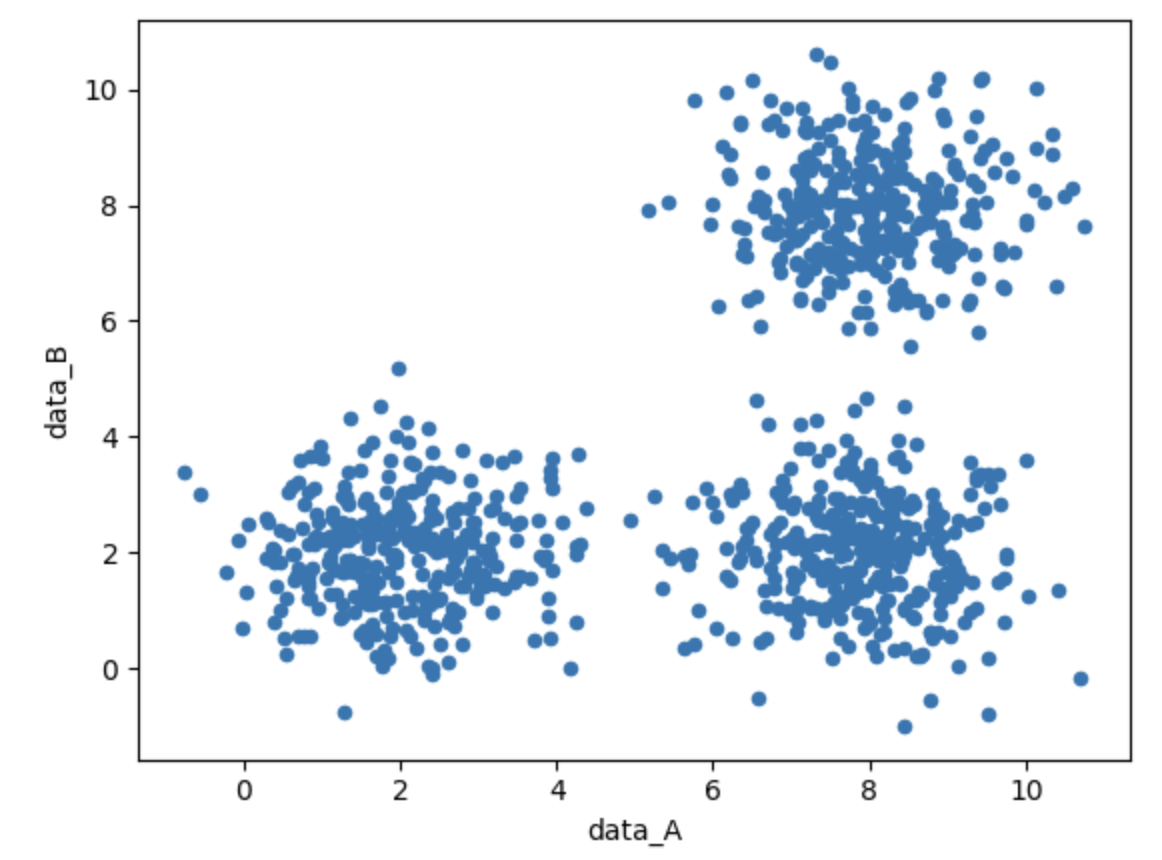

In [23]:
from IPython.display import Image
Image("threeclouds.png")

Would you expect to see a correlation for this challenge problem?  (Hint: does knowing the value of data_A tell you anything about the value of data_B - in particular, whether it is large or small?)  If you managed to reproduce the graph using data, test it yourself using the corr() function.

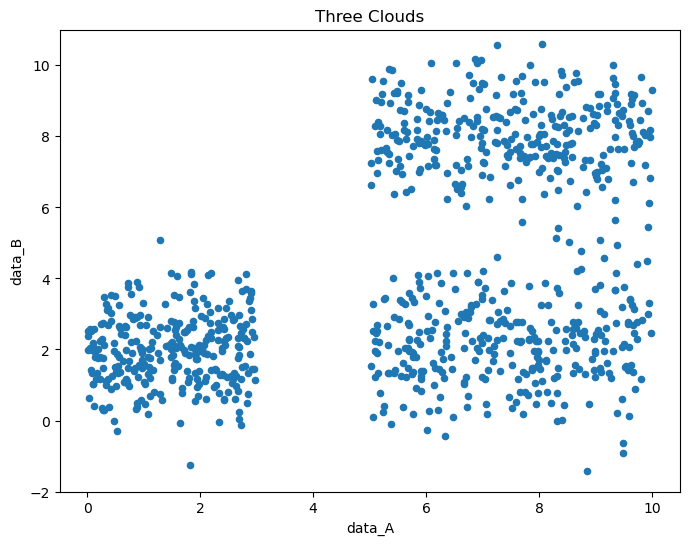

Correlation: 0.4598


In [24]:
num_points = 300
np.random.seed(42)

segx = 5
segy = 10
seg_loc = 2
seg_scale = 1

# Create three segments where segment 2 is in the far right area but BELOW segment 3
# Lower-left cloud: x in [0.5-3], y centered at 2
x_seg1 = np.random.uniform(segx-5, segy-7, num_points)
y_seg1 = np.random.normal(loc=seg_loc, scale=seg_scale, size=num_points)

# Middle cloud: x in [7-10], y centered BELOW segment 3
x_seg2 = np.random.uniform(segx, segy, num_points)
y_seg2 = np.random.normal(loc=seg_loc, scale=seg_scale+0.2, size=num_points)  # Below segment 3

# Upper-right cloud: x in [7-10], y centered at 8
x_seg3 = np.random.uniform(segx, segy, num_points)
y_seg3 = np.random.normal(loc=seg_loc + 6, scale=seg_scale, size=num_points)

# Concatenate all three segments
x_three_clouds_modified = np.concatenate([x_seg1, x_seg2, x_seg3])
y_three_clouds_modified = np.concatenate([y_seg1, y_seg2, y_seg3])

# Create DataFrame and plot
df_three_modified = pd.DataFrame({"data_A": x_three_clouds_modified, "data_B": y_three_clouds_modified})
df_three_modified.plot.scatter(x="data_A", y="data_B", figsize=(8, 6))
plt.title("Three Clouds")
plt.ylim(-2, 11)
plt.show()
plt.close()

# Check correlation
print(f"Correlation: {df_three_modified['data_A'].corr(df_three_modified['data_B']):.4f}")

Here is a histogram.  Can you provide data that will approximately re-create this histogram?

It is okay if the precise numbers are not re-created; just the general shape: tailing off on either side, but tailing off to a nonzero number.  (In this case, about 300).

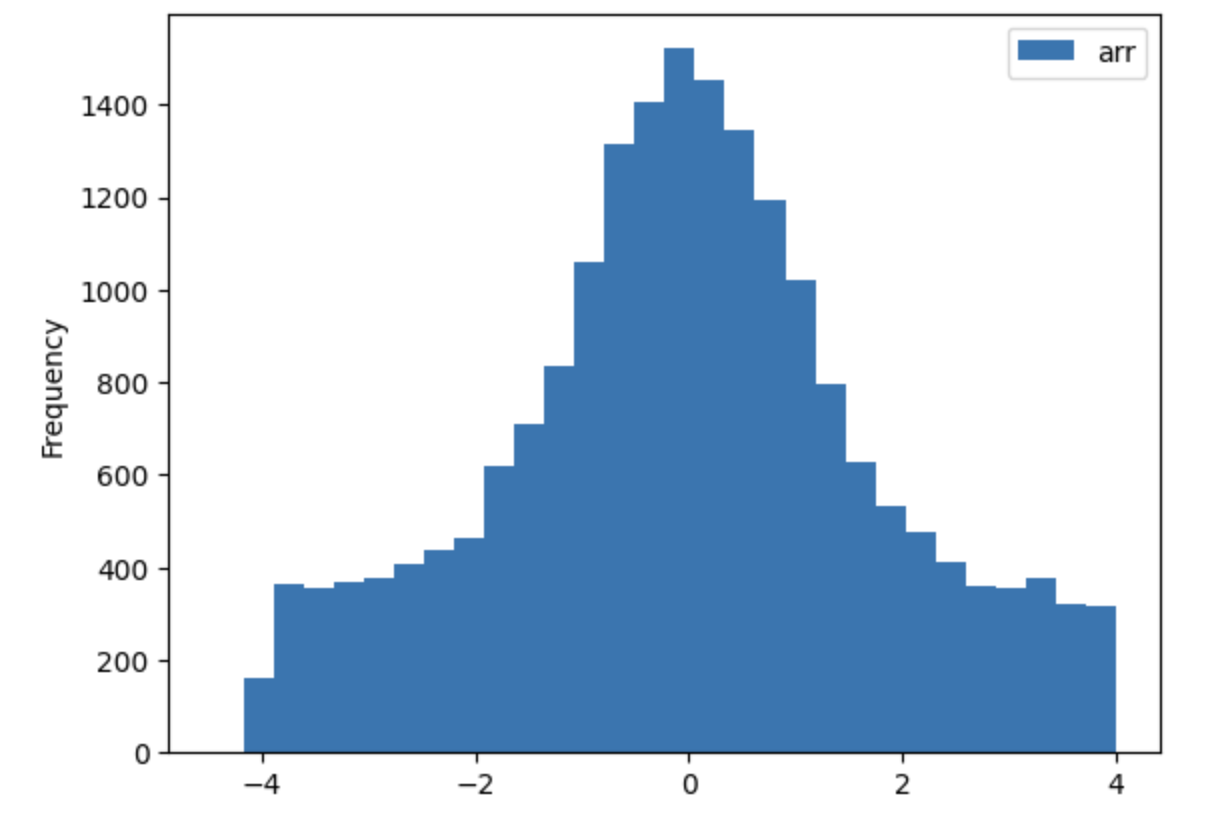

In [25]:
from IPython.display import Image
Image("histogram.png")

Create a line plot that shows a sales volume of soft drinks that decreases, then increases over the course of a year, in a U-shaped curve, but with some noise.

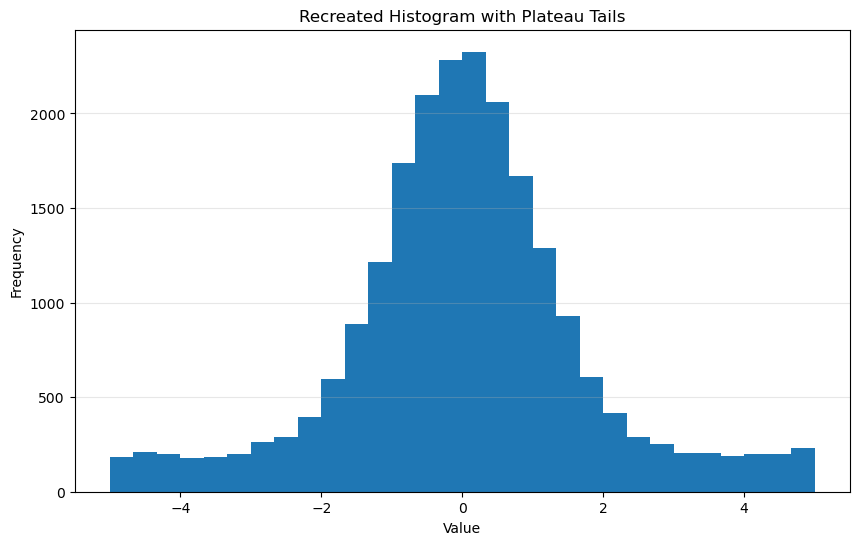

In [26]:
np.random.seed(42)

num_normal = 16000
data_normal = np.random.normal(loc=0, scale=1.0, size=num_normal)

num_uniform = 6000
data_uniform = np.random.uniform(-5, 5, size=num_uniform)

histogram_data = np.concatenate([data_normal, data_uniform])

plt.figure(figsize=(10, 6))
plt.hist(histogram_data, bins=30, color='#1f77b4')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Recreated Histogram with Plateau Tails')
plt.grid(axis='y', alpha=0.3)
plt.show()
plt.close()

Create an area plot that shows the sales volume for two brands of soft drinks, one of which is increasing then decreasing, the other decreasing then increasing.

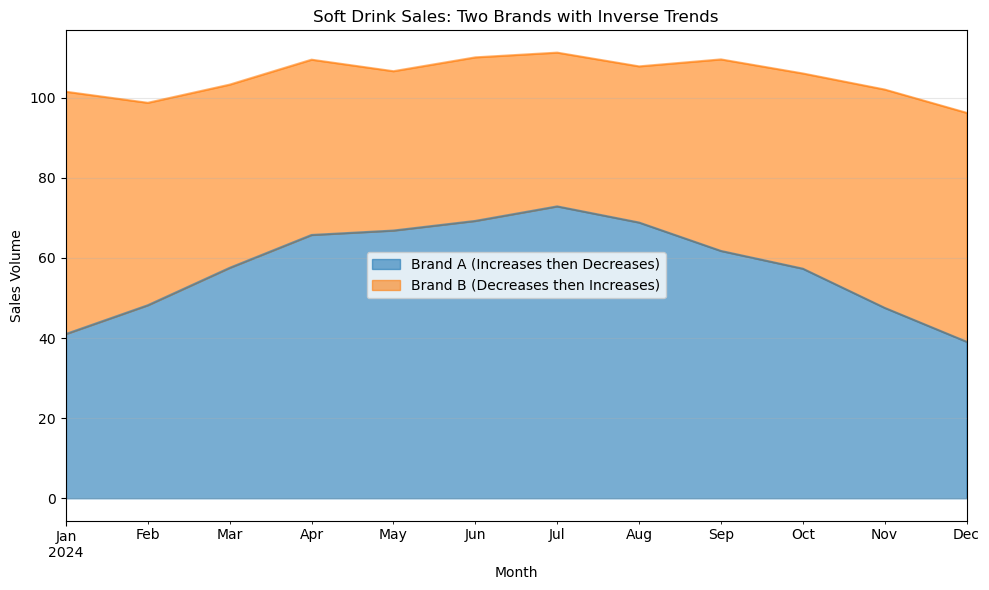

In [27]:
np.random.seed(42)

# Create monthly data for a year (12 months)
months = np.arange(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Brand 1: Increases then decreases (peak in summer)
# Follows a parabolic shape with peak around month 7
brand1_sales = 40 + 30 * np.sin(np.pi * (months - 1) / 11) + np.random.normal(0, 2, 12)

# Brand 2: Decreases then increases (valley in summer)
# Inverse of brand 1
brand2_sales = 60 - 20 * np.sin(np.pi * (months - 1) / 11) + np.random.normal(0, 2, 12)

# Create DataFrame with date index and descriptive column names
date_index = pd.date_range(start='2024-01-01', periods=12, freq='MS')
df_drinks = pd.DataFrame({
    'Brand A (Increases then Decreases)': brand1_sales,
    'Brand B (Decreases then Increases)': brand2_sales
}, index=date_index)

# Create area plot
df_drinks.plot.area(figsize=(10, 6), alpha=0.6, color=['#1f77b4', '#ff7f0e'])
plt.title('Soft Drink Sales: Two Brands with Inverse Trends')
plt.xlabel('Month')
plt.ylabel('Sales Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 71-85 of the Storytelling With Data book as best you can.  (The first half of chapter three).

### convert data from book to pandas dataframe

In [28]:
import pandas as pd

data = [
    {"factor": "Colleague recommendation", "percent": 4},
    {"factor": "Previous work together", "percent": 17},
    {"factor": "Affordability of services", "percent": 19},
    {"factor": "National reputation", "percent": 21},
    {"factor": "Local knowledge", "percent": 42},
    {"factor": "Content expertise", "percent": 53},
    {"factor": "Demonstration of results", "percent": 72},
]

df = pd.DataFrame(data)
df

,factor,percent
0,Colleague recommendation,4
1,Previous work together,17
2,Affordability of services,19
3,National reputation,21
4,Local knowledge,42
5,Content expertise,53
6,Demonstration of results,72


### Horizontal histogram plot from page 82 of STD

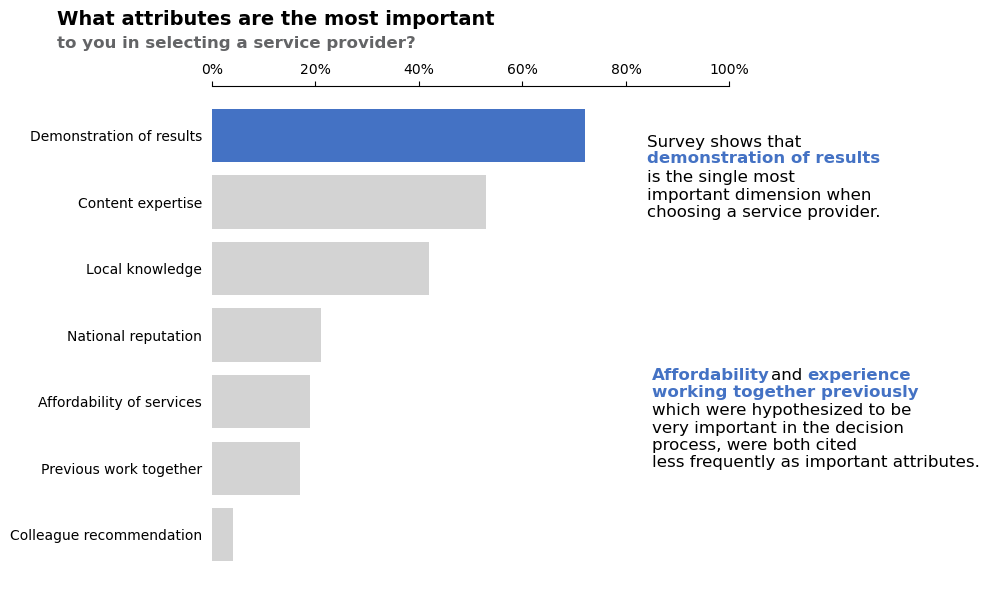

In [29]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import PercentFormatter

# Sort data by percent (descending)
df_sorted = df.sort_values('percent', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars with strategic color (highlight the top item)
colors = ['#4472C4' if i == len(df_sorted)-1 else '#D3D3D3' for i in range(len(df_sorted))]
bars = ax.barh(df_sorted['factor'], df_sorted['percent'], color=colors)

# Remove chart clutter
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(True)

# Show x-axis on top and change to display as percentages
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))

# Clean up y-axis
ax.tick_params(left=False)
ax.set_ylabel('')

# Set x-axis limits with more padding for annotations
ax.set_xlim(0, 100)

# create text for annotations
annotation0 = 'to you in selecting a service provider?'
annotation1 = 'Survey shows that'
annotation2 = 'demonstration of results'
annotation3 = 'is the single most'
annotation4 = 'important dimension when'
annotation5 = 'choosing a service provider.'
annotation6 = 'Affordability'
annotation7 = 'and'
annotation8 = 'experience'
annotation9 = 'working together previously'
annotation10 = 'which were hypothesized to be'
annotation11 = 'very important in the decision'
annotation12 = 'process, were both cited'
annotation13 = 'less frequently as important attributes.'

# coordinates for annotation
annotation_start_x = 84
annotation_start_y = 2.75
title_start_x = -30
title_start_y = 7.6

# format annotations using ax.text for positioning and formatting
# bottom annotation
ax.text(annotation_start_x+1, annotation_start_y-0.25, f'\n\n{annotation10}\n{annotation11}\n{annotation12}\n{annotation13}',
        fontsize=12, va='top', ha='left')
ax.text(annotation_start_x+24, annotation_start_y-0.25, f'{annotation7}',
        fontsize=12, va='top', ha='left')
ax.text(annotation_start_x+31, annotation_start_y-0.25, f'{annotation8}',
        fontsize=12, fontweight='bold', va='top', ha='left',
        color='#4472C4')
ax.text(annotation_start_x+1, annotation_start_y-0.25, annotation6,
        fontsize=12, fontweight='bold', va='top', ha='left',
        color='#4472C4')
ax.text(annotation_start_x+1, annotation_start_y-0.5, annotation9,
        fontsize=12, fontweight='bold', va='top', ha='left',
        color='#4472C4')
# top annotation
ax.text(annotation_start_x, annotation_start_y+3.25, f'{annotation1}\n\n{annotation3}\n{annotation4}\n{annotation5}',
        fontsize=12, va='top', ha='left')
ax.text(annotation_start_x, annotation_start_y+3.02, annotation2,
        fontsize=12, fontweight='bold', va='top', ha='left',
        color='#4472C4')

# add title using ax.text for better control over positioning
ax.text(title_start_x, title_start_y, 'What attributes are the most important', 
        fontsize=14, fontweight='bold', va='bottom', ha='left')
ax.text(title_start_x, title_start_y-0.1, annotation0,
        fontsize=12, fontweight='bold', va='top', ha='left',
        color="#636466")

plt.tight_layout()
plt.show()
# close the plot to recover memory - change if this needs to be referenced later 
plt.close()